<a href="https://colab.research.google.com/github/LuanBui1801/Bai-Tap-AI-Bui-Thanh-Luan-/blob/BT_AI_RAP001/Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install folium geopy osmnx networkx geopandas

In [17]:
import folium #23.1
trung_tam=[10.7801, 106.6953]
cac_dia_diem = [
    ["Dinh Độc Lập", 10.7771, 106.6954, "green"],
    ["Hồ Con Rùa", 10.7826, 106.6958, "orange"],
    ["Bệnh viện Nhi Đồng 2", 10.7818, 106.7003, "red"],
    ["Bưu điện Thành phố", 10.7799, 106.7001, "purple"]
]
m = folium.Map(location=trung_tam, zoom_start=16)
folium.Marker(location=trung_tam, popup="Đại học Kinh tế TP.HCM (UEH)").add_to(m)
for ten, vi_do, kinh_do, mau in cac_dia_diem:
    folium.Marker(location=[vi_do, kinh_do], popup=ten).add_to(m)
folium.LayerControl().add_to(m)
folium.LatLngPopup().add_to(m)
m

In [18]:
import folium #23.2
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time
geolocator = Nominatim(user_agent="My AI MAP APP")
ueh_name = "Đại học kinh tế TP.HCM"
ueh_coords = [10.7801,106.6953]
dia_chi_list=[
    "Vincom Center, Quận 1, TP.HCM",
    "Nhà thờ Đức Bà, Quận 1, TP.HCM",
    "Chợ Bến Thành, Quận 1 , TP.HCM",
    "Landmark 81, Bình Thạnh, TP.HCM ",
    "Đầm Sen, Quận 11, TP.HCM",
    "Saigon Centre, Quận 1, TP.HCM",
    "Thảo Cầm Viên, Quận 1, TP.HCM",
    "Diamond Plaza, Quận 1, TP.HCM",
    "Nhà hát Thành phố, Quận 1, TP.HCM",
    "Bưu điện Trung tâm, Quận 1, TP.HCM"
]
m = folium.Map(location=ueh_coords, zoom_start=16)
folium.Marker(ueh_coords, popup="Điểm Gốc: UEH").add_to(m)
for address in dia_chi_list:
  try:
    location = geolocator.geocode(address)
    if location :
      address_coords = [location.latitude,location.longitude]
      khoang_cach = geodesic(ueh_coords, address_coords).km
      print(f"{address[:40]:<40} {khoang_cach:.2f} km")
      folium.Marker(location=address_coords, popup=f"{address}: {khoang_cach:.2f} km", tooltip="Click xem khoảng cách").add_to(m)
      folium.PolyLine(locations=[ueh_coords, address_coords], color='red', weight=6).add_to(m)
    time.sleep(1)
  except Exception as e:
          print(f"Lỗi khi xử lý {address}: {e}")
m

Vincom Center, Quận 1, TP.HCM            0.75 km
Chợ Bến Thành, Quận 1 , TP.HCM           1.56 km
Landmark 81, Bình Thạnh, TP.HCM          6.31 km
Đầm Sen, Quận 11, TP.HCM                 6.59 km
Saigon Centre, Quận 1, TP.HCM            1.04 km
Thảo Cầm Viên, Quận 1, TP.HCM            1.48 km
Diamond Plaza, Quận 1, TP.HCM            0.36 km
Nhà hát Thành phố, Quận 1, TP.HCM        0.95 km


In [19]:
import folium #23.3
from folium.plugins import HeatMap
import numpy as np
center_coords = [10.7769, 106.7009]
m = folium.Map(location = center_coords, zoom_start = 13)
data = [
    [10.7769, 106.7009, 0.9], [10.7770, 106.7010, 0.8], [10.7750, 106.7000, 0.7],
    [10.7780, 106.7020, 0.9], [10.7800, 106.7030, 0.6], [10.7720, 106.6980, 0.8],
    [10.7710, 106.6950, 0.5], [10.7790, 106.7050, 0.4], [10.7740, 106.7015, 0.9],
    [10.7600, 106.6800, 0.3], [10.7610, 106.6810, 0.4], [10.7590, 106.6790, 0.5],
    [10.8000, 106.7200, 0.2], [10.8010, 106.7210, 0.3], [10.7990, 106.7190, 0.2]
]
heatmap_layer = HeatMap(data, name="Mật độ phân bổ", radius=25, blur=15, min_opacity=0.5)
heatmap_layer.add_to(m)
folium.LayerControl().add_to(m)
m

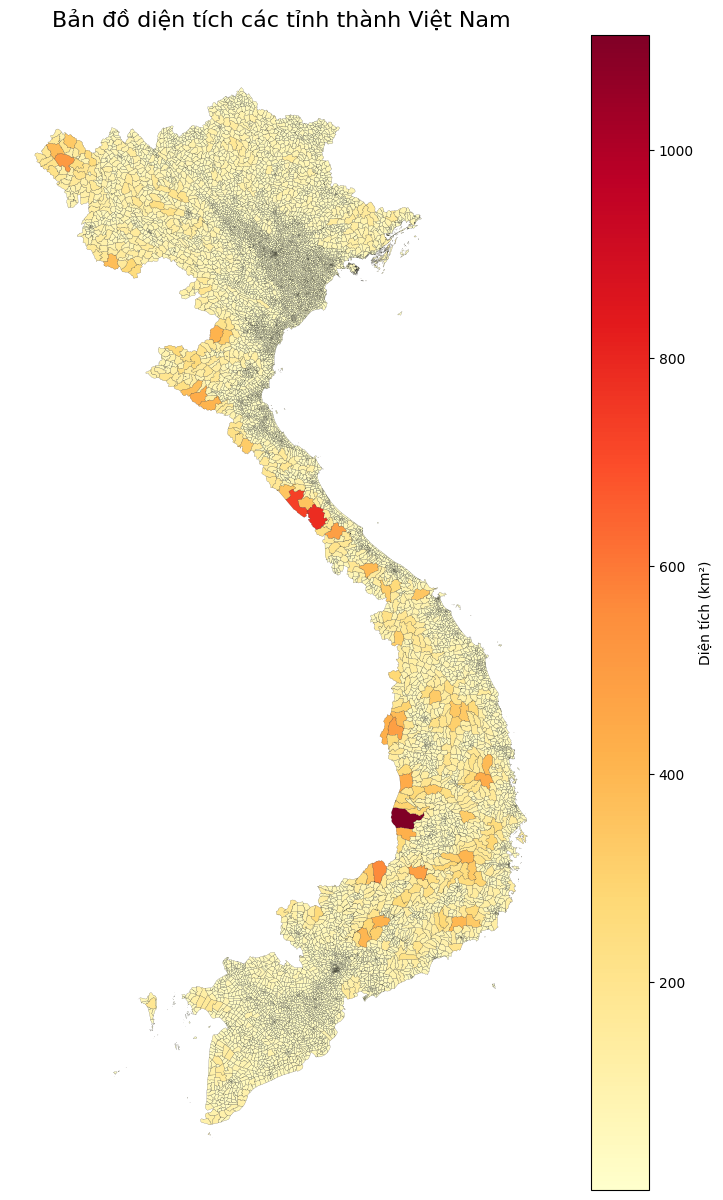

In [21]:
import geopandas as gpd     #23.4
import matplotlib.pyplot as plt
try:
    vietnam_provinces = gpd.read_file("/content/gadm41_VNM_3.json")
    vietnam_provinces = vietnam_provinces.to_crs(epsg=3405)
    vietnam_provinces['area_km2'] = vietnam_provinces['geometry'].area / 10**6
    fig, ax = plt.subplots(1, 1, figsize=(10, 15))
    vietnam_provinces.plot(
        column='area_km2',
        ax=ax,
        legend=True,
        cmap='YlOrRd',
        legend_kwds={'label': "Diện tích (km²)", 'orientation': "vertical"},
        edgecolor='black',
        linewidth=0.1
    )
    plt.title("Bản đồ diện tích các tỉnh thành Việt Nam", fontsize=16)
    ax.set_axis_off()

    plt.show()

except Exception as e:
    print(f"Đã xảy ra lỗi khi tải hoặc xử lý dữ liệu: {e}")

In [23]:
import folium      #23.5
trung_tam_coords = [10.7769, 106.7009]
m = folium.Map(location=trung_tam_coords, zoom_start=14)
folium.Marker(location=trung_tam_coords, popup="Trung tâm điều phối").add_to(m)
folium.Circle(location=trung_tam_coords, radius=1000, color='green', fill=True, fill_color='green', fill_opacity=0.3, tooltip="Vùng phục vụ 1km (Ưu tiên)").add_to(m)
folium.Circle(location=trung_tam_coords, radius=3000, color='blue', fill=False, tooltip="Vùng phục vụ 3km").add_to(m)
folium.Circle(location=trung_tam_coords, radius=5000, color='orange', fill=False,tooltip="Giới hạn phục vụ tối đa (3km)").add_to(m)
folium.LayerControl().add_to(m)
m

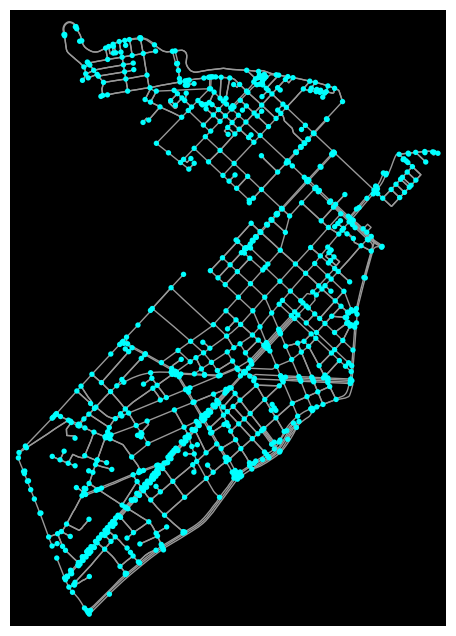

Báo cáo đô thị: Quận 1, TP.HCM, Vietnam
- Số lượng nút giao: 989
- Chiều dài đường trung bình: 79.03 m
- Mật độ mạng lưới: 21449.89 m/km²


In [27]:
import osmnx as ox    #23.6
place_name = "Quận 1, TP.HCM, Vietnam"
gdf = ox.geocode_to_gdf(place_name)
graph = ox.graph_from_place(place_name, network_type = 'drive')
gdf_proj = ox.projection.project_gdf(gdf)
area_meters = gdf_proj.union_all().area
stats = ox.basic_stats(graph, area=area_meters)
ox.plot_graph(graph, node_size = 15, node_color = 'cyan', bgcolor = 'black')
print(f"Báo cáo đô thị: {place_name}")
print(f"- Số lượng nút giao: {stats['n']}")
print(f"- Chiều dài đường trung bình: {stats['edge_length_avg']:.2f} m")
density = stats.get('edge_density_km', stats['edge_length_total'] / (area_meters / 10**6))
print(f"- Mật độ mạng lưới: {density:.2f} m/km²")


In [28]:
import osmnx as ox         #23.7
import networkx as nx
import folium
ox.settings.log_console = True
ox.settings.use_cache = True
place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='walk')
start_point = (10.7770, 106.6953)
end_point = (10.7797, 106.6990)
orig_node = ox.distance.nearest_nodes(G, X=start_point[1], Y=start_point[0])
dest_node = ox.distance.nearest_nodes(G, X=end_point[1], Y=end_point[0])
route_dijkstra = nx.shortest_path(G, orig_node, dest_node, weight='length', method='dijkstra')
len_dijkstra = nx.path_weight(G, route_dijkstra, weight='length')
def heuristic(u, v):
    node_u = G.nodes[u]
    node_v = G.nodes[v]
    return ox.distance.euclidean(node_u['y'], node_u['x'], node_v['y'], node_v['x'])
route_astar = nx.astar_path(G, orig_node, dest_node, heuristic=heuristic, weight='length')
len_astar = nx.path_weight(G, route_astar, weight='length')
m = folium.Map(location=[10.7785, 106.6975], zoom_start=17)
coords_dijkstra = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route_dijkstra]
coords_astar = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route_astar]
folium.PolyLine(coords_dijkstra, color='red', weight=10, opacity=0.6, tooltip="Dijkstra").add_to(m)
folium.PolyLine(coords_astar, color='blue', weight=4, opacity=1, tooltip="A-Star").add_to(m)
folium.Marker(start_point, popup="Xuất phát: Dinh Độc Lập", icon=folium.Icon(color='green')).add_to(m)
folium.Marker(end_point, popup="Đích: Nhà thờ Đức Bà", icon=folium.Icon(color='red')).add_to(m)
print(f"Chiều dài quãng đường Dijkstra: {len_dijkstra:.2f} m")
print(f"Chiều dài quãng đường A*: {len_astar:.2f} m")
m.save("comparison_map.html")
m

Chiều dài quãng đường Dijkstra: 546.69 m
Chiều dài quãng đường A*: 546.69 m


In [35]:
!pip install geopy

In [43]:
import folium      #23.8
from geopy.distance import geodesic
vi_tri_khach = (10.7715, 106.6660)
danh_sach_xe = [
    (10.7752, 106.6631),
    (10.7685, 106.6610),
    (10.7740, 106.6715)
]
khoang_cach_do_duoc=[]
m = folium.Map(location=vi_tri_khach, zoom_start=15)
for stt, toa_do_don_khach in enumerate(danh_sach_xe):
  km = geodesic(toa_do_don_khach,vi_tri_khach).km
  khoang_cach_do_duoc.append(km)
  print(f"Xe {stt+1}: Cách {km:.3f} km (theo đường chim bay)")
  folium.Marker(location=toa_do_don_khach, tooltip=f"Xe số {stt+1}", icon=folium.Icon(color='blue')).add_to(m)
km_ngan_nhat = min(khoang_cach_do_duoc)
vi_tri_index = khoang_cach_do_duoc.index(km_ngan_nhat)
xe_duoc_chon = danh_sach_xe[vi_tri_index]
time_du_kien = (km_ngan_nhat / 30) * 60
print(f"Điều xe số {vi_tri_index + 1} (Dự kiến đến sau khoảng {time_du_kien:.1f} phút)")
folium.PolyLine(locations=[vi_tri_khach,xe_duoc_chon],color="black",weight=4,tooltip=f"Quãng đường: {km_ngan_nhat:.2f} km").add_to(m)
folium.Marker(vi_tri_khach, tooltip="Khách đón xe", icon=folium.Icon(color='green')).add_to(m)
m

Xe 1: Cách 0.518 km (theo đường chim bay)
Xe 2: Cách 0.640 km (theo đường chim bay)
Xe 3: Cách 0.662 km (theo đường chim bay)
Điều xe số 1 (Dự kiến đến sau khoảng 1.0 phút)


In [48]:
import folium                           #23.9
from geopy.distance import geodesic
data = [
    (10.7512, 106.6631),
    (10.7595, 106.6665),
    (10.7480, 106.6540),
    (10.7540, 106.6740)
]
tong_lat = 0
tong_lon = 0
so_luong_kho = len(data)
for lat, lon in data:
  tong_lat += lat
  tong_lon += lon
vi_tri_kho = (tong_lat / so_luong_kho, tong_lon / so_luong_kho)
m = folium.Map(location=vi_tri_kho, zoom_start=14)
folium.Marker(vi_tri_kho, popup=f"Kho hàng tối ưu: {vi_tri_kho}", tooltip="Kho hàng chính", icon=folium.Icon(color='red')).add_to(m)
for n, toa_do in enumerate(data, 1):
  folium.Circle(location=toa_do, radius=10, color="blue", fill=True, fill_color="blue", fill_opacity=0.4, tooltip=f"Kho hàng số {n}").add_to(m)
  folium.PolyLine([vi_tri_kho, toa_do], color='black', weight=4).add_to(m)
vi_tri_khach_hang = (10.7550, 106.6600)
folium.Marker(vi_tri_khach_hang, tooltip='Vị trí của khách', icon=folium.Icon(color='red')).add_to(m)
m


In [29]:
import osmnx as ox   #23.10
import networkx as nx
import folium
from geopy.distance import geodesic
A = (10.760, 106.670)
B = (10.800, 106.710)
vung_ket = (10.775, 106.685)
do_thi = ox.graph_from_point(A, dist=7000, network_type='drive')
node_A = ox.nearest_nodes(do_thi, A[1], A[0])
node_B = ox.nearest_nodes(do_thi, B[1], B[0])
path1 = nx.shortest_path(do_thi, node_A, node_B, weight='length')
trace1 = [[do_thi.nodes[n]['y'], do_thi.nodes[n]['x']] for n in path1]
do_thi_ne = do_thi.copy()
for u, v, data in do_thi_ne.edges(data=True):
    pos = (do_thi_ne.nodes[u]['y'], do_thi_ne.nodes[u]['x'])
    if geodesic(pos, vung_ket).km < 0.3:
        data['length'] = data['length'] * 50
path2 = nx.shortest_path(do_thi_ne, node_A, node_B, weight='length')
trace2 = [[do_thi_ne.nodes[n]['y'], do_thi_ne.nodes[n]['x']] for n in path2]
m = folium.Map(location=[10.775, 106.690], zoom_start=14)
folium.Circle(vung_ket, radius=300, color='red', fill=True, fill_opacity=0.2).add_to(m)
folium.PolyLine(trace1, color='black', weight=2, dash_array='5', opacity=0.5).add_to(m)
folium.PolyLine(trace2, color='darkgreen', weight=5).add_to(m)
folium.Marker(A, icon=folium.Icon(color='blue', icon='info-sign')).add_to(m)
folium.Marker(B, icon=folium.Icon(color='red', icon='info-sign')).add_to(m)
m

In [30]:
import folium  #23.11
from folium.plugins import HeatMap
data_points = [
    [10.816, 106.663, 10], [10.817, 106.665, 9], [10.815, 106.660, 10],
    [10.805, 106.678, 6], [10.806, 106.679, 5], [10.804, 106.677, 6],
    [10.825, 106.675, 2], [10.826, 106.676, 3], [10.824, 106.674, 2]
]
m = folium.Map(location=[10.81, 106.67], zoom_start=14)
HeatMap(data_points, radius=22, blur=18).add_to(m)
folium.Circle(location=[10.816, 106.663], radius=400, color='red', fill=True, popup='Sân bay: Khách chờ rất đông').add_to(m)
folium.Circle(location=[10.805, 106.678], radius=400, color='green', fill=True, popup='Khu ẩm thực: Nhu cầu ổn').add_to(m)
folium.Circle(location=[10.825, 106.675], radius=400, color='blue', fill=True, popup='Vùng ngoại vi: Ít khách').add_to(m)
m

In [31]:
import folium #23.12
from geopy.distance import geodesic
kho_tru_so = {'Kho_1': (10.823, 106.629), 'Kho_2': (10.755, 106.665)}
khach_hang_tong = [
    (10.810, 106.635), (10.835, 106.615), (10.800, 106.640),
    (10.745, 106.675), (10.765, 106.655), (10.730, 106.660)
]
m = folium.Map(location=[10.780, 106.645], zoom_start=13)
tat_ca_khach = []
for ten_kho, toa_do_kho in kho_tru_so.items():
    chua_di = [k for k in khach_hang_tong if min(kho_tru_so.values(), key=lambda x: geodesic(k, x).km) == toa_do_kho]
    if chua_di:
        lo_trinh = [toa_do_kho]
        diem_ht = toa_do_kho
        while chua_di:
            diem_ht = min(chua_di, key=lambda x: geodesic(diem_ht, x).km)
            lo_trinh.append(diem_ht)
            tat_ca_khach.append(diem_ht)
            chua_di.remove(diem_ht)
        lo_trinh.append(toa_do_kho)
        mau = 'green' if ten_kho == 'Kho_1' else 'purple'
        folium.PolyLine(lo_trinh, color=mau, weight=4, opacity=0.7).add_to(m)
for ten_kho, toa_do_kho in kho_tru_so.items():
    folium.Marker(toa_do_kho, icon=folium.Icon(color='red', icon='home')).add_to(m)
for p in tat_ca_khach:
    folium.Marker(p, icon=folium.Icon(color='blue')).add_to(m)
m

In [32]:
import folium                            #23.13
from folium import plugins
m = folium.Map(location=[10.73, 106.72], zoom_start=14)
group1 = folium.FeatureGroup(name='Cac diem kho hang')
folium.Marker([10.729, 106.721], popup='Kho Tong', icon=folium.Icon(color='blue')).add_to(group1)
folium.Marker([10.735, 106.725], popup='Tram trung chuyen 1', icon=folium.Icon(color='blue')).add_to(group1)
folium.Marker([10.720, 106.715], popup='Tram trung chuyen 2', icon=folium.Icon(color='blue')).add_to(group1)
group1.add_to(m)
group2 = folium.FeatureGroup(name='Vung chien luoc')
vung_lay_hang = [[10.74, 106.71], [10.74, 106.73], [10.71, 106.73], [10.71, 106.71]]
folium.Polygon(locations=vung_lay_hang, color='green', fill=True, fill_opacity=0.5).add_to(group2)
group2.add_to(m)
group3 = folium.FeatureGroup(name='Duong di cua xe')
duong_di = [[10.735, 106.725], [10.729, 106.721], [10.720, 106.715]]
folium.PolyLine(locations=duong_di, color='black', weight=3).add_to(group3)
group3.add_to(m)
folium.LayerControl().add_to(m)
plugins.MeasureControl().add_to(m)
m